# Notebook to visualize SAE and bounding boxes related to a sample in PEDRo Dataset

🚀 Initializing Dataset Analysis...

          DATASET ML INSIGHTS           
Total Raw Samples: 11504
Total Objects Detected: 15546
----------------------------------------
Class                | Count      | %    
person               | 15546      | 100.0%
----------------------------------------
Train samples: 9203
Val samples:   1150
Test samples:  1151


STARTING PREPROCESSING: Full_Dataset
 >> Progress:   0.0% | 5/11504 files | 11.14 fps | Elapsed:    0.4s
 >> Progress:   0.1% | 10/11504 files | 12.13 fps | Elapsed:    0.8s
 >> Progress:   0.1% | 15/11504 files | 12.84 fps | Elapsed:    1.2s
 >> Progress:   0.2% | 20/11504 files | 13.10 fps | Elapsed:    1.5s
 >> Progress:   0.2% | 25/11504 files | 11.57 fps | Elapsed:    2.2s
 >> Progress:   0.3% | 30/11504 files | 10.65 fps | Elapsed:    2.8s
 >> Progress:   0.3% | 35/11504 files | 10.43 fps | Elapsed:    3.4s
 >> Progress:   0.3% | 40/11504 files | 10.59 fps | Elapsed:    3.8s
 >> Progress:   0.4% | 45/11504 files | 10.67 fps |

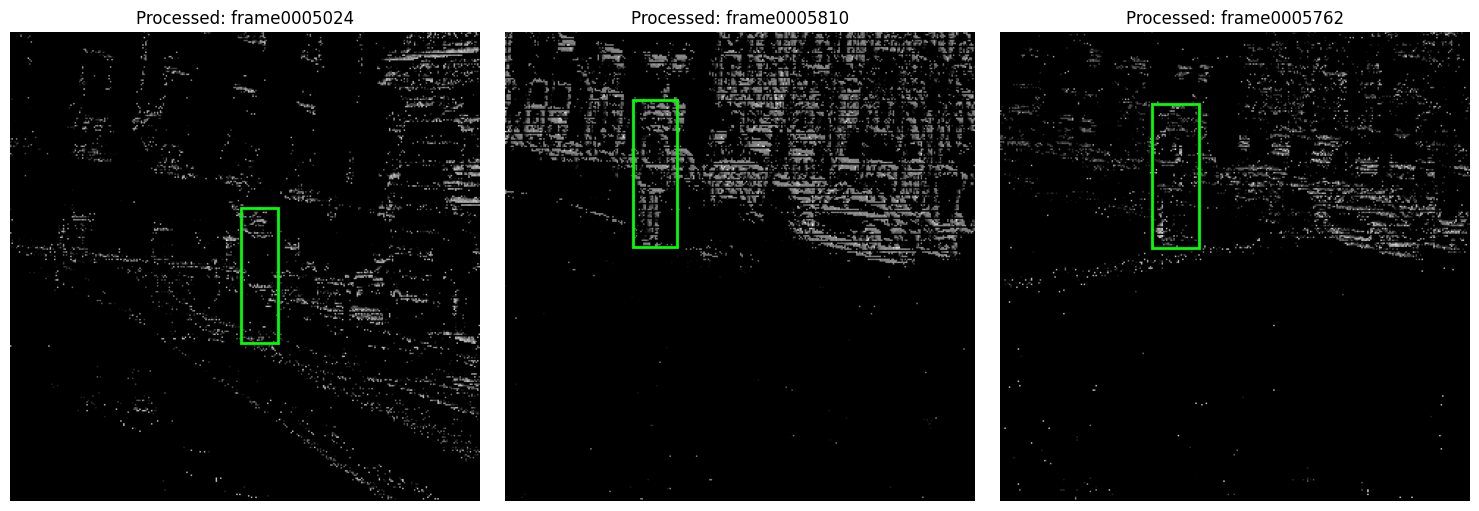

In [86]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from matplotlib.patches import Rectangle
import PIL.Image as Image
from sklearn.model_selection import train_test_split
from collections import Counter
import random

# --- CONFIGURATION ---
dataset_numpy_path = "./numpy/train"
dataset_xml_path = "./xml/train"
output_dir = "./examples/numpy/320x320_PREPROCESSED"
target_res = 320
time_interval = 40e3
random_seed = 42

os.makedirs(output_dir, exist_ok=True)

# 1. DATASET SCANNING & ML ANALYSIS
event_files = sorted(glob.glob(os.path.join(dataset_numpy_path, "*.npy")))
dataset_stats = []
all_labels = []

print("🚀 Initializing Dataset Analysis...")

for file_path in event_files:
    frame_name = os.path.basename(file_path).replace(".npy", "")
    xml_file = os.path.join(dataset_xml_path, f"{frame_name}.xml")
    
    if os.path.exists(xml_file):
        root = ET.parse(xml_file).getroot()
        objs = root.findall('object')
        labels = [obj.find('name').text for obj in objs]
        all_labels.extend(labels)
        dataset_stats.append({
            "file": file_path,
            "xml": xml_file,
            "frame_name": frame_name,
            "obj_count": len(objs)
        })

# Overview Report
class_counts = Counter(all_labels)
df_stats = pd.DataFrame(dataset_stats)

print("\n" + "="*40)
print(f"{'DATASET ML INSIGHTS':^40}")
print("="*40)
print(f"Total Raw Samples: {len(df_stats)}")
print(f"Total Objects Detected: {len(all_labels)}")
print("-" * 40)
print(f"{'Class':<20} | {'Count':<10} | {'%':<5}")
for cls, count in class_counts.items():
    print(f"{cls:<20} | {count:<10} | {count/len(all_labels)*100:>5.1f}%")

# 2. ML SPLITS (Train 80%, Val 10%, Test 10%)
train_df, temp_df = train_test_split(df_stats, test_size=0.2, random_state=random_seed)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=random_seed)

print("-" * 40)
print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")
print(f"Test samples:  {len(test_df)}")
print("="*40 + "\n")

# 3. PROCESSING & SAVING GRAYSCALE SAE
import time # Added for performance tracking

import time

def process_and_save(dataframe, split_name):
    print(f"\n{'='*40}")
    print(f"STARTING PREPROCESSING: {split_name}")
    print(f"{'='*40}")
    
    total_files = len(dataframe)
    start_time = time.time()
    count = 0
    corrupted_files = [] # Track the bad ones
    total_objects_scaled = 0

    for idx, (_, row) in enumerate(dataframe.iterrows(), 1):
        try:
            # 1. XML Handling & Scaling
            tree = ET.parse(row['xml'])
            root = tree.getroot()
            orig_w = int(root.find("size")[0].text)
            orig_h = int(root.find("size")[1].text)
            scale_x, scale_y = target_res / orig_w, target_res / orig_h
            
            root.find("size")[0].text = str(target_res)
            root.find("size")[1].text = str(target_res)
            objects = root.findall('object')

            # 2. SAE Logic (The crash happened here)
            events = np.load(row['file']) # Attempt to load
            
            # If load succeeds, proceed with processing
            x_scaled = (events[:, 1] * scale_x).astype(int)
            y_scaled = (events[:, 2] * scale_y).astype(int)
            
            df_ev = pd.DataFrame({'t': events[:, 0], 'x': x_scaled, 'y': y_scaled, 'p': events[:, 3]})
            df_ev = df_ev[(df_ev['x'] < target_res) & (df_ev['y'] < target_res)]
            
            if df_ev.empty:
                continue
            
            t_max = df_ev['t'].iloc[-1]
            t_min = t_max - time_interval
            
            sae = np.zeros((target_res, target_res, 2), dtype='float32')
            for pol, channel in [(0, 1), (1, 0)]:
                subset = df_ev[df_ev['p'] == pol].sort_values('t').drop_duplicates(['x', 'y'], keep='last')
                subset = subset[subset['t'] >= t_min]
                if not subset.empty:
                    norm_t = (255 * (subset['t'] - t_min) / time_interval).astype(np.uint8)
                    sae[subset['y'], subset['x'], channel] = norm_t

            # 3. Grayscale Conversion & Saving
            grayscale_sae = (0.5 * sae[:,:,0] + 0.5 * sae[:,:,1]).astype(np.uint8)
            img = Image.fromarray(grayscale_sae).convert("L")
            
            # Update XML bboxes only if event processing was successful
            for obj in objects:
                bbox = obj.find('bndbox')
                bbox.find('xmin').text = str(int(int(bbox.find('xmin').text) * scale_x))
                bbox.find('ymin').text = str(int(int(bbox.find('ymin').text) * scale_y))
                bbox.find('xmax').text = str(int(int(bbox.find('xmax').text) * scale_x))
                bbox.find('ymax').text = str(int(int(bbox.find('ymax').text) * scale_y))
            
            total_objects_scaled += len(objects)
            img.save(os.path.join(output_dir, f"{row['frame_name']}.png"))
            tree.write(os.path.join(output_dir, f"{row['frame_name']}.xml"))
            count += 1

        except (ValueError, OSError, EOFError) as e:
            # This catches corrupted .npy files
            print(f" [!] ERROR: Could not read {row['frame_name']}. Skipping. Reason: {e}")
            corrupted_files.append(row['file'])
            continue

        # --- LOGGING EVERY 5 FRAMES ---
        if idx % 5 == 0 or idx == total_files:
            percent = (idx / total_files) * 100
            elapsed = time.time() - start_time
            fps = idx / elapsed if elapsed > 0 else 0
            print(f" >> Progress: {percent:>5.1f}% | {idx}/{total_files} files | {fps:>5.2f} fps | Elapsed: {elapsed:>6.1f}s")

    print(f"\n✅ FINISHED: {split_name}")
    print(f" - Successfully saved: {count} images/XMLs")
    if corrupted_files:
        print(f" - ⚠️  SKIPPED {len(corrupted_files)} corrupted files.")
    return count

# Run the fixed version
total_saved = process_and_save(df_stats, "Full_Dataset")

# 4. FINAL VISUALIZATION
processed_images = glob.glob(os.path.join(output_dir, "*.png"))
samples = random.sample(processed_images, min(len(processed_images), 3))
fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))



for i, img_path in enumerate(samples):
    name = os.path.basename(img_path).replace(".png", "")
    ax = axes[i] if len(samples) > 1 else axes
    ax.imshow(Image.open(img_path), cmap='gray')
    
    # Overlay Scaled XML Bboxes
    root = ET.parse(os.path.join(output_dir, f"{name}.xml")).getroot()
    for obj in root.findall('object'):
        b = obj.find('bndbox')
        x1, y1, x2, y2 = int(b[0].text), int(b[1].text), int(b[2].text), int(b[3].text)
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='lime', fill=False, lw=2))
    ax.set_title(f"Processed: {name}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [91]:
# The actual library is PyYAML
!pip install PyYAML

import os
import shutil
import yaml
import xml.etree.ElementTree as ET # Ensure ET is available in this cell

# --- CONFIGURATION ---
input_dir = "./examples/numpy/320x320_PREPROCESSED" 
yolo_dataset_dir = "./yolo_dataset"
classes = ["person"] 

# 1. CREATE YOLO DIRECTORY STRUCTURE
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(yolo_dataset_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dataset_dir, 'labels', split), exist_ok=True)

def convert_to_yolo(xml_file, target_res=320):
    """Converts XML coordinates to normalized YOLO format."""
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        yolo_data = []
        
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name not in classes: continue
            
            class_id = classes.index(name)
            bbox = obj.find('bndbox')
            
            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)
            
            # YOLO format: normalized center_x, center_y, width, height
            dw = 1. / target_res
            dh = 1. / target_res
            x_center = (xmin + xmax) / 2.0 * dw
            y_center = (ymin + ymax) / 2.0 * dh
            w = (xmax - xmin) * dw
            h = (ymax - ymin) * dh
            
            yolo_data.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
        return yolo_data
    except Exception as e:
        print(f"Error processing {xml_file}: {e}")
        return []

# 2. DISTRIBUTE FILES INTO SPLITS
# Re-using the train_df, val_df, test_df from your previous ML Split step
splits = {'train': train_df, 'val': val_df, 'test': test_df}

print("📦 Starting YOLO Conversion...")
for split_name, df in splits.items():
    converted_count = 0
    for _, row in df.iterrows():
        frame_name = row['frame_name']
        img_src = os.path.join(input_dir, f"{frame_name}.png")
        xml_src = os.path.join(input_dir, f"{frame_name}.xml")
        
        if os.path.exists(img_src) and os.path.exists(xml_src):
            img_dst = os.path.join(yolo_dataset_dir, 'images', split_name, f"{frame_name}.png")
            txt_dst = os.path.join(yolo_dataset_dir, 'labels', split_name, f"{frame_name}.txt")
            
            yolo_lines = convert_to_yolo(xml_src)
            
            if yolo_lines: 
                with open(txt_dst, 'w') as f:
                    f.write("\n".join(yolo_lines))
                shutil.copy(img_src, img_dst)
                converted_count += 1
    
    print(f" -> {split_name}: {converted_count} samples converted.")

# 3. CREATE DATA.YAML (The Ultra-Important Part)
# Use relative paths from the perspective of where you run the training
config = {
    'path': os.path.abspath(yolo_dataset_dir), # absolute path for safety
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 1,              # Number of classes
    'names': ['person']   # List of names
}

with open(os.path.join(yolo_dataset_dir, 'data.yaml'), 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"\n🚀 Done! Dataset ready at: {yolo_dataset_dir}")

  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (807 kB)
📦 Starting YOLO Conversion...
 -> train: 9202 samples converted.
 -> val: 1150 samples converted.
 -> test: 1151 samples converted.

🚀 Done! Dataset ready at: ./yolo_dataset


In [13]:
import sys
!{sys.executable} -m pip uninstall -y tensorflow tf-keras keras numpy akida akida-models cnn2snn quantizeml onnx tf2onnx

Found existing installation: tensorflow 2.19.1
Uninstalling tensorflow-2.19.1:
  Successfully uninstalled tensorflow-2.19.1
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3
Found existing installation: akida 2.19.1
Uninstalling akida-2.19.1:
  Successfully uninstalled akida-2.19.1
Found existing installation: akida_models 1.13.1
Uninstalling akida_models-1.13.1:
  Successfully uninstalled akida_models-1.13.1
Found existing installation: cnn2snn 2.19.1
Uninstalling cnn2snn-2.19.1:
  Successfully uninstalled cnn2snn-2.19.1
Found existing installation: quantizeml 1.2.3
Uninstalling quantizeml-1.2.3:
  Successfully uninstalled quantizeml-1.2.3
Found existing installation: onnx 1.20.1
Uninstalling onnx-1.20.1:
 

In [14]:
import sys
# This installs the primary engine. We use 'tensorflow' (which includes Keras 3 now)
# and the latest Akida tools compatible with it.
!{sys.executable} -m pip install "tensorflow>=2.16" "akida>=2.19.1" "cnn2snn>=2.19.1" "quantizeml>=1.2.3" "numpy<2.0"

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached akida-2.19.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (822 bytes)
  Using cached cnn2snn-2.19.1-py3-none-any.whl
  Using cached quantizeml-1.2.3-py3-none-any.whl
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached protobuf-6.33.5-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached tf_keras-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow-2.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached onnx-1.20.1-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cac

In [15]:
import sys
!{sys.executable} -m pip install onnx tf2onnx matplotlib scikit-learn pyyaml akida-models

  Using cached tf2onnx-1.16.1-py3-none-any.whl.metadata (1.3 kB)
  Using cached akida_models-1.13.1-py3-none-any.whl
INFO: pip is looking at multiple versions of tf2onnx to determine which version is compatible with other requirements. This could take a while.
  Using cached tf2onnx-1.16.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached tf2onnx-1.15.1-py3-none-any.whl.metadata (1.2 kB)
  Using cached tf2onnx-1.15.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached flatbuffers-2.0.7-py2.py3-none-any.whl.metadata (872 bytes)
  Using cached tf2onnx-1.14.0-py3-none-any.whl.metadata (1.2 kB)
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Using cached onnxruntime-1.23.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.1 kB)
INFO: pip is still looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a

In [1]:
try:
    import tensorflow as tf
    import akida
    import cnn2snn
    import tf_keras
    print(f"✅ TensorFlow: {tf.__version__}")
    print(f"✅ Akida: {akida.__version__}")
    print(f"✅ CNN2SNN: {cnn2snn.__version__}")
    print("\n🚀 WE ARE LIVE! You can start training now.")
except Exception as e:
    print(f"❌ Verification failed: {e}")

2026-02-25 23:59:11.613409: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 23:59:11.621921: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 23:59:11.670243: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 23:59:11.721503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772060351.776570  210284 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772060351.79

✅ TensorFlow: 2.19.1
✅ Akida: 2.19.1
✅ CNN2SNN: 2.19.1

🚀 WE ARE LIVE! You can start training now.


Python Executable: /home/antonio/Desktop/metavision-toolbox/IEBCS/app/.venv/bin/python
---
Pip thinks it's installing here:
TensorFlow NOT FOUND by pip


In [ ]:
import numpy as np
# Force numpy to have the 'object' attribute that tf2onnx is looking for
if not hasattr(np, 'object'):
    np.object = object
if not hasattr(np, 'bool'):
    np.bool = bool

# NOW run your imports
import tf2onnx
import tensorflow as tf
import akida
print("✅ Patch applied and imports successful!")

import json
import os
import re
from collections import Counter
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt
import numpy as np
import tf_keras as keras
from akida_models import akidanet_imagenet
from sklearn.metrics import (
    accuracy_score,
    auc as sk_auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tf_keras import Input, Model, layers

# --- CONFIGURATION ---
os.environ["TF_USE_LEGACY_KERAS"] = "1"
IMG_SIZE = 320
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "8"))
EPOCHS = int(os.getenv("EPOCHS", "10")) # Povećano jer sad imamo što učiti

YOLO_DATASET_PATH = Path("./yolo_dataset")
OUTPUT_DIR = Path("./outputs")
BEST_SAVE_PATH = OUTPUT_DIR / "best_person_detection.keras"

# 0 = human, 1 = not human
CATEGORY_MAP = {"human": 0, "not human": 1}

# --- DATA LOADING & SYNTHETIC NOISE GENERATION ---

def load_yolo_split(split: str):
    image_paths, labels = [], []
    img_dir = YOLO_DATASET_PATH / "images" / split
    lbl_dir = YOLO_DATASET_PATH / "labels" / split

    if not img_dir.exists():
        return np.array([]), np.array([], dtype=np.int32)

    valid_exts = (".png", ".jpg", ".jpeg")
    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() in valid_exts:
            txt_path = lbl_dir / (img_path.stem + ".txt")
            # Ako postoji labela, to je čovjek
            if txt_path.exists() and os.path.getsize(txt_path) > 0:
                image_paths.append(str(img_path))
                labels.append(CATEGORY_MAP["human"])
    
    return np.array(image_paths), np.array(labels, dtype=np.int32)

def create_balanced_dataset(paths, labels, split_name="train"):
    """
    Dodaje sintetički šum kako bi uravnotežio klasu 'čovjek' i 'nema čovjeka'.
    PAŽNJA: Ovo je samo za testiranje logike treninga!
    """
    num_positives = np.sum(labels == 0)
    print(f"[{split_name}] Found {num_positives} positive samples. Generating noise for balance...")
    
    # Generiramo nasumični šum koji oponaša event data (prazan prostor)
    # 0.5% - 2% gustoća piksela je tipična za Event-based šum
    noise_data = np.random.choice([0.0, 1.0], 
                                  size=(num_positives, IMG_SIZE, IMG_SIZE, 1), 
                                  p=[0.99, 0.01]).astype(np.float32)
    noise_labels = np.ones(num_positives, dtype=np.int32)
    
    return paths, labels, noise_data, noise_labels

# --- PREPROCESSING ---

def parse_real_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image.set_shape([IMG_SIZE, IMG_SIZE, 1])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def train_augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 20, IMG_SIZE + 20)
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 1])
    return image, label

def prepare_final_ds(paths, labels, noise_imgs, noise_lbls, augment=False):
    # Dataset od pravih slika
    real_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    real_ds = real_ds.map(parse_real_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Dataset od generiranog šuma
    noise_ds = tf.data.Dataset.from_tensor_slices((noise_imgs, noise_lbls))
    
    # Spajanje
    full_ds = real_ds.concatenate(noise_ds)
    
    if augment:
        full_ds = full_ds.map(train_augment, num_parallel_calls=tf.data.AUTOTUNE)
    
    return full_ds.shuffle(len(labels)*2).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- MODEL ---

def create_akida_model():
    base_model = akidanet_imagenet(input_shape=(IMG_SIZE, IMG_SIZE, 1), include_top=False, pooling='avg')
    base_model.trainable = True 
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = base_model(inputs)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="logits")(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

# --- EXECUTION ---

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Load samo pozitivne (ljude)
tr_p, tr_l = load_yolo_split("train")
vl_p, vl_l = load_yolo_split("val")
ts_p, ts_l = load_yolo_split("test")

# 2. Balansiranje sa šumom
tr_p, tr_l, tr_n_img, tr_n_lbl = create_balanced_dataset(tr_p, tr_l, "Train")
vl_p, vl_l, vl_n_img, vl_n_lbl = create_balanced_dataset(vl_p, vl_l, "Val")
ts_p, ts_l, ts_n_img, ts_n_lbl = create_balanced_dataset(ts_p, ts_l, "Test")

# 3. Build Datasets
train_ds = prepare_final_ds(tr_p, tr_l, tr_n_img, tr_n_lbl, augment=True)
valid_ds = prepare_final_ds(vl_p, vl_l, vl_n_img, vl_n_lbl)
test_ds = prepare_final_ds(ts_p, ts_l, ts_n_img, ts_n_lbl)

print(f"\n✅ Balanced Dataset Ready. Train size: {len(tr_l)*2}")

# 4. Train
model = create_akida_model()
callbacks = [
    keras.callbacks.ModelCheckpoint(str(BEST_SAVE_PATH), monitor="val_loss", save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = model.fit(train_ds, validation_data=valid_ds, epochs=EPOCHS, callbacks=callbacks)

# 5. Evaluation
print("\n📊 Evaluating on Balanced Test Set...")
model = keras.models.load_model(str(BEST_SAVE_PATH), compile=False)
model.compile(loss="binary_crossentropy", metrics=["accuracy"])

# Priprema labela za evaluaciju (pravi + šum)
y_true = np.concatenate([ts_l, ts_n_lbl])
y_probs = model.predict(test_ds).reshape(-1)
y_pred = (y_probs >= 0.5).astype(int)

# Report
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*40)
print(f"ACCURACY: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-SCORE: {f1_score(y_true, y_pred):.4f}")
print("-" * 40)
print("Confusion Matrix (0=Human, 1=Noise):")
print(cm)
print("="*40)

# Čuvanje krivulja
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='loss'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history['accuracy'], label='acc'); plt.legend()
plt.savefig(OUTPUT_DIR / "training_curves.png")
print(f"✅ Training complete. Model saved to {BEST_SAVE_PATH}")

/tmp/ipykernel_243764/2739452281.py:3: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'):
2026-02-26 10:11:40.518173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 10:11:40.525640: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 10:11:40.587467: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 10:11:40.652943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772097100.718458  243764

✅ Patch applied and imports successful!


2026-02-26 10:11:47.977052: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[Train] Found 9202 positive samples. Generating noise for balance...
